# Загрузка библиотек

In [1]:
import pandas as pd
import sys
import pickle
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC
from IPython.display import display, HTML

In [2]:
sys.path.append('../utils_functionality/')
from data_analysis.split_analisys import *
from data_analysis.reports import *
from models.class_models import *
from models.class_models import *
from models.hyperparams_tuning import *
from models.blending import *

Imported 0.2.6 version. Select nrows to a small number when running on huge datasets.
output = featurewiz(dataname, target, corr_limit=0.90, verbose=2, sep=',', 
		header=0, test_data='',feature_engg='', category_encoders='',
		dask_xgboost_flag=False, nrows=None, skip_sulov=False)
Create new features via 'feature_engg' flag : ['interactions','groupby','target']



In [ ]:
import wandb
wandb.login(key='8b1f2ae49570ea59dc8612ff434ca497d463d221')

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
RANDOM_STATE = 42
N_TRIALS = 500

# Загрузка данных и разделение на train, test

In [6]:
df = pd.read_excel('../data/df_merged_edited.xlsx', index_col=[0])
df.reset_index(inplace=True, drop=True)
train, test = train_test_split(df, test_size=0.33, random_state=RANDOM_STATE)

In [7]:
# логирование 
df_logs = pd.DataFrame(columns=['Таргет', 'Модель', 'Датасет', 'F1', 'ROC AUC'])

# splashing

## 1. CatBoost + SMOTENC + optuna

### Original Dataset

In [8]:
features = ['Re', 'We', 'particle_liquid_density_ratio',
             'wettability', 'roughness', 'surface_tension', 'liquid_density']

In [9]:
cs = CreateSamples(df, train, test, target='splashing', features=features)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,liquid_density,surface_tension,particle_liquid_density_ratio,wettability,roughness,Re,We
31,1140,0.0691,0.877193,neutral,0.04,2110.385675,833.534028
36,1140,0.0691,0.877193,lyophilic,10.89,2022.562172,798.846587
158,1180,0.0679,1.864407,lyophobic,2.49,661.664919,891.662791
183,1180,0.0679,0.847458,lyophilic,0.10,649.524278,875.302006
168,820,0.0269,1.219512,neutral,0.04,1466.205641,1465.995744


In [10]:
cat_features = [3]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
best_trial_cb = get_best_trial(X_train, X_test, y_train, y_test, cat_indexes=cat_features, n_trials=N_TRIALS, timeout=None)
model = CatBoostClassifier(**best_trial_cb.params, cat_features=cat_features, verbose=False)
model.fit(X_train, y_train)
model.save_model('../utils_functionality/models/models_pickles/tuned_models/splashing_original_1')
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [12]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.867647,0.907692,0.887218,65.000000
1,0.890909,0.844828,0.867257,58.000000
accuracy,0.878049,0.878049,0.878049,0.878049
macro avg,0.879278,0.876260,0.877237,123.000000
weighted avg,0.878616,0.878049,0.877805,123.000000


In [13]:
df_logs = df_logs.append(pd.DataFrame({
    'Таргет': ['splashing'],
    'Модель': ['CatBoost + SMOTENC + optuna'],
    'Датасет': ['original'],
    'F1': [f1],
    'ROC AUC': [roc]
}))

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='CatBoost + SMOTENC + optuna, splashing, original'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

### United Dataset

In [15]:
features = ['Re', 'We', 'wettability', 'roughness', 'inclination', 
            'particle_mean_diameter', 'particle_liquid_density_ratio', 'surface_tension', 'viscosity']

In [16]:
cs = CreateSamples(df, train, test, target='splashing', features=features)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,inclination,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,wettability,roughness,Re,We
31,0,0.0691,0.00689,0.000041,0.877193,neutral,0.04,2110.385675,833.534028
36,0,0.0691,0.00689,0.000041,0.877193,lyophilic,10.89,2022.562172,798.846587
158,0,0.0679,0.02310,0.000041,1.864407,lyophobic,2.49,661.664919,891.662791
183,0,0.0679,0.02310,0.000041,0.847458,lyophilic,0.10,649.524278,875.302006
168,0,0.0269,0.00679,0.000041,1.219512,neutral,0.04,1466.205641,1465.995744


In [17]:
cat_features = [0, 5]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
best_trial_cb = get_best_trial(X_train, X_test, y_train, y_test, cat_indexes=cat_features, n_trials=N_TRIALS, timeout=None)
model = CatBoostClassifier(**best_trial_cb.params, cat_features=cat_features, verbose=False)
model.fit(X_train, y_train)
model.save_model('../utils_functionality/models/models_pickles/tuned_models/splashing_united_1')
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [19]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.855072,0.907692,0.880597,65.000000
1,0.888889,0.827586,0.857143,58.000000
accuracy,0.869919,0.869919,0.869919,0.869919
macro avg,0.871981,0.867639,0.868870,123.000000
weighted avg,0.871018,0.869919,0.869537,123.000000


In [20]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["splashing"],
            "Модель": ["CatBoost + SMOTENC + optuna"],
            "Датасет": ["united"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='CatBoost + SMOTENC + optuna, splashing, united'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

### Alternative Dataset

In [22]:
features = ['Re', 'We', 'wettability', 'roughness_binary', 'inclination', 
            'particle_mean_diameter', 'particle_liquid_density_ratio',
            'volume_fraction_binary', 'surface_tension', 'viscosity']

In [23]:
cs = CreateSamples(df, train, test, target='splashing', features=features)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,inclination,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,wettability,roughness_binary,volume_fraction_binary,Re,We
31,0,0.0691,0.00689,0.000041,0.877193,neutral,0,1,2110.385675,833.534028
36,0,0.0691,0.00689,0.000041,0.877193,lyophilic,1,1,2022.562172,798.846587
158,0,0.0679,0.02310,0.000041,1.864407,lyophobic,0,0,661.664919,891.662791
183,0,0.0679,0.02310,0.000041,0.847458,lyophilic,0,1,649.524278,875.302006
168,0,0.0269,0.00679,0.000041,1.219512,neutral,0,0,1466.205641,1465.995744


In [24]:
cat_features = [0, 5]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
best_trial_cb = get_best_trial(X_train, X_test, y_train, y_test, cat_indexes=cat_features, n_trials=N_TRIALS, timeout=None)
model = CatBoostClassifier(**best_trial_cb.params, cat_features=cat_features, verbose=False)
model.fit(X_train, y_train)
model.save_model('../utils_functionality/models/models_pickles/tuned_models/splashing_alternative_1')
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [26]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.871429,0.938462,0.903704,65.000000
1,0.924528,0.844828,0.882883,58.000000
accuracy,0.894309,0.894309,0.894309,0.894309
macro avg,0.897978,0.891645,0.893293,123.000000
weighted avg,0.896467,0.894309,0.893886,123.000000


In [27]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["splashing"],
            "Модель": ["CatBoost + SMOTENC + optuna"],
            "Датасет": ["alternative"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='CatBoost + SMOTENC + optuna, splashing, alternative'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

### PF Dataset

In [29]:
features = ['Re', 'We', 'wettability', 'roughness', 'inclination', 
            'particle_mean_diameter', 'particle_liquid_density_ratio', 
            'surface_tension', 'viscosity']

In [30]:
cs = CreateSamples(df, train, test, target='splashing', features=features, get_pf=True)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,inclination,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,wettability,roughness,Re,We,Re_1/4,We_1/4,Re_1/4^2,Re_1/4 We_1/4,We_1/4^2
31,0,0.0691,0.00689,0.000041,0.877193,neutral,0.04,2110.385675,833.534028,6.777827,5.373173,45.938934,36.418436,28.870989
36,0,0.0691,0.00689,0.000041,0.877193,lyophilic,10.89,2022.562172,798.846587,6.706184,5.316378,44.972905,35.652609,28.263874
158,0,0.0679,0.02310,0.000041,1.864407,lyophobic,2.49,661.664919,891.662791,5.071770,5.464497,25.722848,27.714668,29.860723
183,0,0.0679,0.02310,0.000041,0.847458,lyophilic,0.10,649.524278,875.302006,5.048343,5.439256,25.485766,27.459228,29.585503
168,0,0.0269,0.00679,0.000041,1.219512,neutral,0.04,1466.205641,1465.995744,6.187977,6.187756,38.291065,38.289694,38.288324


In [31]:
cat_features = [0, 5]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
best_trial_cb = get_best_trial(X_train, X_test, y_train, y_test, cat_indexes=cat_features, n_trials=N_TRIALS, timeout=None)
model = CatBoostClassifier(**best_trial_cb.params, cat_features=cat_features, verbose=False)
model.fit(X_train, y_train)
model.save_model('../utils_functionality/models/models_pickles/tuned_models/splashing_pf_1')
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [33]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.882353,0.923077,0.902256,65.000000
1,0.909091,0.862069,0.884956,58.000000
accuracy,0.894309,0.894309,0.894309,0.894309
macro avg,0.895722,0.892573,0.893606,123.000000
weighted avg,0.894961,0.894309,0.894098,123.000000


In [34]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["splashing"],
            "Модель": ["CatBoost + SMOTENC + optuna"],
            "Датасет": ["pf"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='CatBoost + SMOTENC + optuna, splashing, pf'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

## 2. RandomForest + SMOTENC + optuna

### Original Dataset

In [36]:
features = ['Re', 'We', 'particle_liquid_density_ratio',
             'wettability', 'roughness', 'surface_tension', 'liquid_density']

In [37]:
cs = CreateSamples(df, train, test, target='splashing', features=features)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,liquid_density,surface_tension,particle_liquid_density_ratio,wettability,roughness,Re,We
31,1140,0.0691,0.877193,neutral,0.04,2110.385675,833.534028
36,1140,0.0691,0.877193,lyophilic,10.89,2022.562172,798.846587
158,1180,0.0679,1.864407,lyophobic,2.49,661.664919,891.662791
183,1180,0.0679,0.847458,lyophilic,0.10,649.524278,875.302006
168,820,0.0269,1.219512,neutral,0.04,1466.205641,1465.995744


In [38]:
cat_features = [3]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)
X_train = pd.get_dummies(X_train, columns=X_train.columns[cat_features])
X_test = pd.get_dummies(X_test, columns=X_test.columns[cat_features])

In [ ]:
best_trial_rf = get_best_trial(X_train, X_test, y_train, y_test, n_trials=N_TRIALS, timeout=None, cb=False, rf=True)
model = RandomForestClassifier(**best_trial_rf.params)
model.fit(X_train, y_train)
pickle.dump(model, open('../utils_functionality/models/models_pickles/tuned_models/splashing_original_2.pkl', 'wb'))
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [40]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.867647,0.907692,0.887218,65.000000
1,0.890909,0.844828,0.867257,58.000000
accuracy,0.878049,0.878049,0.878049,0.878049
macro avg,0.879278,0.876260,0.877237,123.000000
weighted avg,0.878616,0.878049,0.877805,123.000000


In [41]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["splashing"],
            "Модель": ["RandomForest + SMOTENC + optuna"],
            "Датасет": ["original"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='RandomForest + SMOTENC + optuna, splashing, original'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

### United Dataset

In [43]:
features = ['Re', 'We', 'wettability', 'roughness', 'inclination', 
            'particle_mean_diameter', 'particle_liquid_density_ratio', 'surface_tension', 'viscosity']

In [44]:
cs = CreateSamples(df, train, test, target='splashing', features=features)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,inclination,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,wettability,roughness,Re,We
31,0,0.0691,0.00689,0.000041,0.877193,neutral,0.04,2110.385675,833.534028
36,0,0.0691,0.00689,0.000041,0.877193,lyophilic,10.89,2022.562172,798.846587
158,0,0.0679,0.02310,0.000041,1.864407,lyophobic,2.49,661.664919,891.662791
183,0,0.0679,0.02310,0.000041,0.847458,lyophilic,0.10,649.524278,875.302006
168,0,0.0269,0.00679,0.000041,1.219512,neutral,0.04,1466.205641,1465.995744


In [45]:
cat_features = [0, 5]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)
X_train = pd.get_dummies(X_train, columns=X_train.columns[cat_features])
X_test = pd.get_dummies(X_test, columns=X_test.columns[cat_features])

In [ ]:
best_trial_rf = get_best_trial(X_train, X_test, y_train, y_test, n_trials=N_TRIALS, timeout=None, cb=False, rf=True)
model = RandomForestClassifier(**best_trial_rf.params)
model.fit(X_train, y_train)
pickle.dump(model, open('../utils_functionality/models/models_pickles/tuned_models/splashing_united_2.pkl', 'wb'))
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [47]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.867647,0.907692,0.887218,65.000000
1,0.890909,0.844828,0.867257,58.000000
accuracy,0.878049,0.878049,0.878049,0.878049
macro avg,0.879278,0.876260,0.877237,123.000000
weighted avg,0.878616,0.878049,0.877805,123.000000


In [48]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["splashing"],
            "Модель": ["RandomForest + SMOTENC + optuna"],
            "Датасет": ["united"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='RandomForest + SMOTENC + optuna, splashing, united'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

### Alternative Dataset

In [50]:
features = ['Re', 'We', 'wettability', 'roughness_binary', 'inclination', 
            'particle_mean_diameter', 'particle_liquid_density_ratio',
            'volume_fraction_binary', 'surface_tension', 'viscosity']

In [51]:
cs = CreateSamples(df, train, test, target='splashing', features=features)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,inclination,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,wettability,roughness_binary,volume_fraction_binary,Re,We
31,0,0.0691,0.00689,0.000041,0.877193,neutral,0,1,2110.385675,833.534028
36,0,0.0691,0.00689,0.000041,0.877193,lyophilic,1,1,2022.562172,798.846587
158,0,0.0679,0.02310,0.000041,1.864407,lyophobic,0,0,661.664919,891.662791
183,0,0.0679,0.02310,0.000041,0.847458,lyophilic,0,1,649.524278,875.302006
168,0,0.0269,0.00679,0.000041,1.219512,neutral,0,0,1466.205641,1465.995744


In [52]:
cat_features = [0, 5]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)
X_train = pd.get_dummies(X_train, columns=X_train.columns[cat_features])
X_test = pd.get_dummies(X_test, columns=X_test.columns[cat_features])

In [ ]:
best_trial_rf = get_best_trial(X_train, X_test, y_train, y_test, n_trials=N_TRIALS, timeout=None, cb=False, rf=True)
model = RandomForestClassifier(**best_trial_rf.params)
model.fit(X_train, y_train)
pickle.dump(model, open('../utils_functionality/models/models_pickles/tuned_models/splashing_alternative_2.pkl', 'wb'))
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [54]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.845070,0.923077,0.882353,65.000000
1,0.903846,0.810345,0.854545,58.000000
accuracy,0.869919,0.869919,0.869919,0.869919
macro avg,0.874458,0.866711,0.868449,123.000000
weighted avg,0.872786,0.869919,0.869240,123.000000


In [55]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["splashing"],
            "Модель": ["RandomForest + SMOTENC + optuna"],
            "Датасет": ["alternative"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='RandomForest + SMOTENC + optuna, splashing, alternative'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

### PF Dataset

In [57]:
features = ['Re', 'We', 'wettability', 'roughness', 'inclination', 
            'particle_mean_diameter', 'particle_liquid_density_ratio', 
            'surface_tension', 'viscosity']

In [58]:
cs = CreateSamples(df, train, test, target='splashing', features=features, get_pf=True)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,inclination,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,wettability,roughness,Re,We,Re_1/4,We_1/4,Re_1/4^2,Re_1/4 We_1/4,We_1/4^2
31,0,0.0691,0.00689,0.000041,0.877193,neutral,0.04,2110.385675,833.534028,6.777827,5.373173,45.938934,36.418436,28.870989
36,0,0.0691,0.00689,0.000041,0.877193,lyophilic,10.89,2022.562172,798.846587,6.706184,5.316378,44.972905,35.652609,28.263874
158,0,0.0679,0.02310,0.000041,1.864407,lyophobic,2.49,661.664919,891.662791,5.071770,5.464497,25.722848,27.714668,29.860723
183,0,0.0679,0.02310,0.000041,0.847458,lyophilic,0.10,649.524278,875.302006,5.048343,5.439256,25.485766,27.459228,29.585503
168,0,0.0269,0.00679,0.000041,1.219512,neutral,0.04,1466.205641,1465.995744,6.187977,6.187756,38.291065,38.289694,38.288324


In [59]:
cat_features = [0, 5]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)
X_train = pd.get_dummies(X_train, columns=X_train.columns[cat_features])
X_test = pd.get_dummies(X_test, columns=X_test.columns[cat_features])

In [ ]:
best_trial_rf = get_best_trial(X_train, X_test, y_train, y_test, n_trials=N_TRIALS, timeout=None, cb=False, rf=True)
model = RandomForestClassifier(**best_trial_rf.params)
model.fit(X_train, y_train)
pickle.dump(model, open('../utils_functionality/models/models_pickles/tuned_models/splashing_pf_2.pkl', 'wb'))
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [61]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.848485,0.861538,0.854962,65.000000
1,0.842105,0.827586,0.834783,58.000000
accuracy,0.845528,0.845528,0.845528,0.845528
macro avg,0.845295,0.844562,0.844872,123.000000
weighted avg,0.845477,0.845528,0.845446,123.000000


In [62]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["splashing"],
            "Модель": ["RandomForest + SMOTENC + optuna"],
            "Датасет": ["pf"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='RandomForest + SMOTENC + optuna, splashing, pf'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

## 3. KNN  + SMOTENC + optuna

### Original Dataset

In [64]:
features = ['Re', 'We', 'particle_liquid_density_ratio',
             'wettability', 'roughness', 'surface_tension', 'liquid_density']

In [65]:
cs = CreateSamples(df, train, test, target='splashing', features=features)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,liquid_density,surface_tension,particle_liquid_density_ratio,wettability,roughness,Re,We
31,1140,0.0691,0.877193,neutral,0.04,2110.385675,833.534028
36,1140,0.0691,0.877193,lyophilic,10.89,2022.562172,798.846587
158,1180,0.0679,1.864407,lyophobic,2.49,661.664919,891.662791
183,1180,0.0679,0.847458,lyophilic,0.10,649.524278,875.302006
168,820,0.0269,1.219512,neutral,0.04,1466.205641,1465.995744


In [66]:
cat_features = [3]
numerical_features = [0, 1, 2, 4, 5, 6]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)
X_train = pd.get_dummies(X_train, columns=X_train.columns[cat_features])
X_test = pd.get_dummies(X_test, columns=X_test.columns[cat_features])
scaler = StandardScaler()
X_train.iloc[:, numerical_features] = scaler.fit_transform(X_train.iloc[:, numerical_features])
X_test.iloc[:, numerical_features] = scaler.fit_transform(X_test.iloc[:, numerical_features])

In [ ]:
best_trial_knn = get_best_trial(X_train, X_test, y_train, y_test, n_trials=N_TRIALS, timeout=None, cb=False, rf=False, knn=True)
model = KNeighborsClassifier(**best_trial_knn.params)
model.fit(X_train, y_train)
pickle.dump(model, open('../utils_functionality/models/models_pickles/tuned_models/splashing_original_3.pkl', 'wb'))
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [68]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.855072,0.907692,0.880597,65.000000
1,0.888889,0.827586,0.857143,58.000000
accuracy,0.869919,0.869919,0.869919,0.869919
macro avg,0.871981,0.867639,0.868870,123.000000
weighted avg,0.871018,0.869919,0.869537,123.000000


In [69]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["splashing"],
            "Модель": ["KNN + SMOTENC + optuna"],
            "Датасет": ["original"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='KNN + SMOTENC + optuna, splashing, original'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

### United Dataset

In [71]:
features = ['Re', 'We', 'wettability', 'roughness', 'inclination', 
            'particle_mean_diameter', 'particle_liquid_density_ratio', 'surface_tension', 'viscosity']

In [72]:
cs = CreateSamples(df, train, test, target='splashing', features=features)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,inclination,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,wettability,roughness,Re,We
31,0,0.0691,0.00689,0.000041,0.877193,neutral,0.04,2110.385675,833.534028
36,0,0.0691,0.00689,0.000041,0.877193,lyophilic,10.89,2022.562172,798.846587
158,0,0.0679,0.02310,0.000041,1.864407,lyophobic,2.49,661.664919,891.662791
183,0,0.0679,0.02310,0.000041,0.847458,lyophilic,0.10,649.524278,875.302006
168,0,0.0269,0.00679,0.000041,1.219512,neutral,0.04,1466.205641,1465.995744


In [73]:
cat_features = [0, 5]
numerical_features = [1,2,3,4,6,7,8]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)
X_train = pd.get_dummies(X_train, columns=X_train.columns[cat_features])
X_test = pd.get_dummies(X_test, columns=X_test.columns[cat_features])
scaler = StandardScaler()
X_train.iloc[:, numerical_features] = scaler.fit_transform(X_train.iloc[:, numerical_features])
X_test.iloc[:, numerical_features] = scaler.fit_transform(X_test.iloc[:, numerical_features])

In [ ]:
best_trial_knn = get_best_trial(X_train, X_test, y_train, y_test, n_trials=N_TRIALS, timeout=None, cb=False, rf=False, knn=True)
model = KNeighborsClassifier(**best_trial_knn.params)
model.fit(X_train, y_train)
pickle.dump(model, open('../utils_functionality/models/models_pickles/tuned_models/splashing_united_3.pkl', 'wb'))
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [75]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.742857,0.800000,0.770370,65.000000
1,0.754717,0.689655,0.720721,58.000000
accuracy,0.747967,0.747967,0.747967,0.747967
macro avg,0.748787,0.744828,0.745546,123.000000
weighted avg,0.748450,0.747967,0.746958,123.000000


In [76]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["splashing"],
            "Модель": ["KNN + SMOTENC + optuna"],
            "Датасет": ["united"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='KNN + SMOTENC + optuna, splashing, united'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

### Alternative Dataset

In [78]:
features = ['Re', 'We', 'wettability', 'roughness_binary', 'inclination', 
            'particle_mean_diameter', 'particle_liquid_density_ratio',
            'volume_fraction_binary', 'surface_tension', 'viscosity']

In [79]:
cs = CreateSamples(df, train, test, target='splashing', features=features)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,inclination,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,wettability,roughness_binary,volume_fraction_binary,Re,We
31,0,0.0691,0.00689,0.000041,0.877193,neutral,0,1,2110.385675,833.534028
36,0,0.0691,0.00689,0.000041,0.877193,lyophilic,1,1,2022.562172,798.846587
158,0,0.0679,0.02310,0.000041,1.864407,lyophobic,0,0,661.664919,891.662791
183,0,0.0679,0.02310,0.000041,0.847458,lyophilic,0,1,649.524278,875.302006
168,0,0.0269,0.00679,0.000041,1.219512,neutral,0,0,1466.205641,1465.995744


In [80]:
cat_features = [0, 5]
numerical_features = [1, 2, 3, 4, 7, 8]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)
X_train = pd.get_dummies(X_train, columns=X_train.columns[cat_features])
X_test = pd.get_dummies(X_test, columns=X_test.columns[cat_features])
scaler = StandardScaler()
X_train.iloc[:, numerical_features] = scaler.fit_transform(X_train.iloc[:, numerical_features])
X_test.iloc[:, numerical_features] = scaler.fit_transform(X_test.iloc[:, numerical_features])

In [ ]:
best_trial_knn = get_best_trial(X_train, X_test, y_train, y_test, n_trials=N_TRIALS, timeout=None, cb=False, rf=False, knn=True)
model = KNeighborsClassifier(**best_trial_knn.params)
model.fit(X_train, y_train)
pickle.dump(model, open('../utils_functionality/models/models_pickles/tuned_models/splashing_alternative_3.pkl', 'wb'))
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [82]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.736111,0.815385,0.773723,65.000000
1,0.764706,0.672414,0.715596,58.000000
accuracy,0.747967,0.747967,0.747967,0.747967
macro avg,0.750408,0.743899,0.744659,123.000000
weighted avg,0.749595,0.747967,0.746313,123.000000


In [83]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["splashing"],
            "Модель": ["KNN + SMOTENC + optuna"],
            "Датасет": ["alternative"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='KNN + SMOTENC + optuna, splashing, alternative'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

### PF Dataset

In [85]:
features = ['Re', 'We', 'wettability', 'roughness', 'inclination', 
            'particle_mean_diameter', 'particle_liquid_density_ratio', 
            'surface_tension', 'viscosity']

In [86]:
cs = CreateSamples(df, train, test, target='splashing', features=features, get_pf=True)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,inclination,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,wettability,roughness,Re,We,Re_1/4,We_1/4,Re_1/4^2,Re_1/4 We_1/4,We_1/4^2
31,0,0.0691,0.00689,0.000041,0.877193,neutral,0.04,2110.385675,833.534028,6.777827,5.373173,45.938934,36.418436,28.870989
36,0,0.0691,0.00689,0.000041,0.877193,lyophilic,10.89,2022.562172,798.846587,6.706184,5.316378,44.972905,35.652609,28.263874
158,0,0.0679,0.02310,0.000041,1.864407,lyophobic,2.49,661.664919,891.662791,5.071770,5.464497,25.722848,27.714668,29.860723
183,0,0.0679,0.02310,0.000041,0.847458,lyophilic,0.10,649.524278,875.302006,5.048343,5.439256,25.485766,27.459228,29.585503
168,0,0.0269,0.00679,0.000041,1.219512,neutral,0.04,1466.205641,1465.995744,6.187977,6.187756,38.291065,38.289694,38.288324


In [87]:
cat_features = [0, 5]
numerical_features = [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)
scaler = StandardScaler()
X_train.iloc[:, numerical_features] = scaler.fit_transform(X_train.iloc[:, numerical_features])
X_test.iloc[:, numerical_features] = scaler.fit_transform(X_test.iloc[:, numerical_features])
X_train = pd.get_dummies(X_train, columns=X_train.columns[cat_features])
X_test = pd.get_dummies(X_test, columns=X_test.columns[cat_features])

In [ ]:
best_trial_knn = get_best_trial(X_train, X_test, y_train, y_test, n_trials=N_TRIALS, timeout=None, cb=False, rf=False, knn=True)
model = KNeighborsClassifier(**best_trial_knn.params)
model.fit(X_train, y_train)
pickle.dump(model, open('../utils_functionality/models/models_pickles/tuned_models/splashing_pf_3.pkl', 'wb'))
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [89]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.880597,0.907692,0.893939,65.000000
1,0.892857,0.862069,0.877193,58.000000
accuracy,0.886179,0.886179,0.886179,0.886179
macro avg,0.886727,0.884881,0.885566,123.000000
weighted avg,0.886378,0.886179,0.886043,123.000000


In [90]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["splashing"],
            "Модель": ["KNN + SMOTENC + optuna"],
            "Датасет": ["pf"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='KNN + SMOTENC + optuna, splashing, pf'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

# net_impact

## 1. CatBoost + SMOTENC + optuna

### Original Dataset

In [92]:
features = ['Re', 'We', 'particle_liquid_density_ratio',
             'wettability', 'roughness', 'surface_tension', 'liquid_density']

In [93]:
cs = CreateSamples(df, train, test, target='net_impact', features=features)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,liquid_density,surface_tension,particle_liquid_density_ratio,wettability,roughness,Re,We
31,1140,0.0691,0.877193,neutral,0.04,2110.385675,833.534028
36,1140,0.0691,0.877193,lyophilic,10.89,2022.562172,798.846587
158,1180,0.0679,1.864407,lyophobic,2.49,661.664919,891.662791
183,1180,0.0679,0.847458,lyophilic,0.10,649.524278,875.302006
168,820,0.0269,1.219512,neutral,0.04,1466.205641,1465.995744


In [94]:
cat_features = [3]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
best_trial_cb = get_best_trial(X_train, X_test, y_train, y_test, cat_indexes=cat_features, n_trials=N_TRIALS, timeout=None)
model = CatBoostClassifier(**best_trial_cb.params, cat_features=cat_features, verbose=False)
model.fit(X_train, y_train)
model.save_model('../utils_functionality/models/models_pickles/tuned_models/net_impact_original_1')
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [96]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.942029,0.792683,0.860927,82.000000
1,0.685185,0.902439,0.778947,41.000000
accuracy,0.829268,0.829268,0.829268,0.829268
macro avg,0.813607,0.847561,0.819937,123.000000
weighted avg,0.856414,0.829268,0.833601,123.000000


In [97]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["net_impact"],
            "Модель": ["CatBoost + SMOTENC + optuna"],
            "Датасет": ["original"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='CatBoost + SMOTENC + optuna, net_impact, original'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

### United Dataset

In [99]:
features = ['Re', 'We', 'wettability', 'roughness', 'inclination', 
            'particle_mean_diameter', 'particle_liquid_density_ratio', 'surface_tension', 'viscosity']

In [100]:
cs = CreateSamples(df, train, test, target='net_impact', features=features)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,inclination,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,wettability,roughness,Re,We
31,0,0.0691,0.00689,0.000041,0.877193,neutral,0.04,2110.385675,833.534028
36,0,0.0691,0.00689,0.000041,0.877193,lyophilic,10.89,2022.562172,798.846587
158,0,0.0679,0.02310,0.000041,1.864407,lyophobic,2.49,661.664919,891.662791
183,0,0.0679,0.02310,0.000041,0.847458,lyophilic,0.10,649.524278,875.302006
168,0,0.0269,0.00679,0.000041,1.219512,neutral,0.04,1466.205641,1465.995744


In [101]:
cat_features = [0, 5]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
best_trial_cb = get_best_trial(X_train, X_test, y_train, y_test, cat_indexes=cat_features, n_trials=N_TRIALS, timeout=None)
model = CatBoostClassifier(**best_trial_cb.params, cat_features=cat_features, verbose=False)
model.fit(X_train, y_train)
model.save_model('../utils_functionality/models/models_pickles/tuned_models/net_impact_united_1')
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [103]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.986486,0.890244,0.935897,82.000000
1,0.816327,0.975610,0.888889,41.000000
accuracy,0.918699,0.918699,0.918699,0.918699
macro avg,0.901407,0.932927,0.912393,123.000000
weighted avg,0.929767,0.918699,0.920228,123.000000


In [104]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["net_impact"],
            "Модель": ["CatBoost + SMOTENC + optuna"],
            "Датасет": ["united"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='CatBoost + SMOTENC + optuna, net_impact, united'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

### Alternative Dataset

In [106]:
features = ['Re', 'We', 'wettability', 'roughness_binary', 'inclination', 
            'particle_mean_diameter', 'particle_liquid_density_ratio',
            'volume_fraction_binary', 'surface_tension', 'viscosity']

In [107]:
cs = CreateSamples(df, train, test, target='net_impact', features=features)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,inclination,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,wettability,roughness_binary,volume_fraction_binary,Re,We
31,0,0.0691,0.00689,0.000041,0.877193,neutral,0,1,2110.385675,833.534028
36,0,0.0691,0.00689,0.000041,0.877193,lyophilic,1,1,2022.562172,798.846587
158,0,0.0679,0.02310,0.000041,1.864407,lyophobic,0,0,661.664919,891.662791
183,0,0.0679,0.02310,0.000041,0.847458,lyophilic,0,1,649.524278,875.302006
168,0,0.0269,0.00679,0.000041,1.219512,neutral,0,0,1466.205641,1465.995744


In [108]:
cat_features = [0, 5]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
best_trial_cb = get_best_trial(X_train, X_test, y_train, y_test, cat_indexes=cat_features, n_trials=N_TRIALS, timeout=None)
model = CatBoostClassifier(**best_trial_cb.params, cat_features=cat_features, verbose=False)
model.fit(X_train, y_train)
model.save_model('../utils_functionality/models/models_pickles/tuned_models/net_impact_alternative_1')
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [110]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.987013,0.926829,0.955975,82.000000
1,0.869565,0.975610,0.919540,41.000000
accuracy,0.943089,0.943089,0.943089,0.943089
macro avg,0.928289,0.951220,0.937758,123.000000
weighted avg,0.947864,0.943089,0.943830,123.000000


In [111]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["net_impact"],
            "Модель": ["CatBoost + SMOTENC + optuna"],
            "Датасет": ["alternative"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='CatBoost + SMOTENC + optuna, net_impact, alternative'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

### PF Dataset

In [113]:
features = ['Re', 'We', 'wettability', 'roughness', 'inclination', 
            'particle_mean_diameter', 'particle_liquid_density_ratio', 
            'surface_tension', 'viscosity']

In [114]:
cs = CreateSamples(df, train, test, target='net_impact', features=features, get_pf=True)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,inclination,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,wettability,roughness,Re,We,Re_1/4,We_1/4,Re_1/4^2,Re_1/4 We_1/4,We_1/4^2
31,0,0.0691,0.00689,0.000041,0.877193,neutral,0.04,2110.385675,833.534028,6.777827,5.373173,45.938934,36.418436,28.870989
36,0,0.0691,0.00689,0.000041,0.877193,lyophilic,10.89,2022.562172,798.846587,6.706184,5.316378,44.972905,35.652609,28.263874
158,0,0.0679,0.02310,0.000041,1.864407,lyophobic,2.49,661.664919,891.662791,5.071770,5.464497,25.722848,27.714668,29.860723
183,0,0.0679,0.02310,0.000041,0.847458,lyophilic,0.10,649.524278,875.302006,5.048343,5.439256,25.485766,27.459228,29.585503
168,0,0.0269,0.00679,0.000041,1.219512,neutral,0.04,1466.205641,1465.995744,6.187977,6.187756,38.291065,38.289694,38.288324


In [115]:
cat_features = [0, 5]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
best_trial_cb = get_best_trial(X_train, X_test, y_train, y_test, cat_indexes=cat_features, n_trials=N_TRIALS, timeout=None)
model = CatBoostClassifier(**best_trial_cb.params, cat_features=cat_features, verbose=False)
model.fit(X_train, y_train)
model.save_model('../utils_functionality/models/models_pickles/tuned_models/net_impact_pf_1')
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [117]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.961538,0.914634,0.937500,82.000000
1,0.844444,0.926829,0.883721,41.000000
accuracy,0.918699,0.918699,0.918699,0.918699
macro avg,0.902991,0.920732,0.910610,123.000000
weighted avg,0.922507,0.918699,0.919574,123.000000


In [118]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["net_impact"],
            "Модель": ["CatBoost + SMOTENC + optuna"],
            "Датасет": ["pf"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='CatBoost + SMOTENC + optuna, net_impact, pf'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

## 2. RandomForest + SMOTENC + optuna

### Original Dataset

In [120]:
features = ['Re', 'We', 'particle_liquid_density_ratio',
             'wettability', 'roughness', 'surface_tension', 'liquid_density']

In [121]:
cs = CreateSamples(df, train, test, target='net_impact', features=features)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,liquid_density,surface_tension,particle_liquid_density_ratio,wettability,roughness,Re,We
31,1140,0.0691,0.877193,neutral,0.04,2110.385675,833.534028
36,1140,0.0691,0.877193,lyophilic,10.89,2022.562172,798.846587
158,1180,0.0679,1.864407,lyophobic,2.49,661.664919,891.662791
183,1180,0.0679,0.847458,lyophilic,0.10,649.524278,875.302006
168,820,0.0269,1.219512,neutral,0.04,1466.205641,1465.995744


In [122]:
cat_features = [3]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)
X_train = pd.get_dummies(X_train, columns=X_train.columns[cat_features])
X_test = pd.get_dummies(X_test, columns=X_test.columns[cat_features])

In [ ]:
best_trial_rf = get_best_trial(X_train, X_test, y_train, y_test, n_trials=N_TRIALS, timeout=None, cb=False, rf=True)
model = RandomForestClassifier(**best_trial_rf.params)
model.fit(X_train, y_train)
pickle.dump(model, open('../utils_functionality/models/models_pickles/tuned_models/net_impact_original_2.pkl', 'wb'))
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [124]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.869048,0.890244,0.879518,82.000000
1,0.769231,0.731707,0.750000,41.000000
accuracy,0.837398,0.837398,0.837398,0.837398
macro avg,0.819139,0.810976,0.814759,123.000000
weighted avg,0.835775,0.837398,0.836345,123.000000


In [125]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["net_impact"],
            "Модель": ["RandomForest + SMOTENC + optuna"],
            "Датасет": ["original"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='RandomForest + SMOTENC + optuna, net_impact, original'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

### United Dataset

In [127]:
features = ['Re', 'We', 'wettability', 'roughness', 'inclination', 
            'particle_mean_diameter', 'particle_liquid_density_ratio', 'surface_tension', 'viscosity']

In [128]:
cs = CreateSamples(df, train, test, target='net_impact', features=features)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,inclination,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,wettability,roughness,Re,We
31,0,0.0691,0.00689,0.000041,0.877193,neutral,0.04,2110.385675,833.534028
36,0,0.0691,0.00689,0.000041,0.877193,lyophilic,10.89,2022.562172,798.846587
158,0,0.0679,0.02310,0.000041,1.864407,lyophobic,2.49,661.664919,891.662791
183,0,0.0679,0.02310,0.000041,0.847458,lyophilic,0.10,649.524278,875.302006
168,0,0.0269,0.00679,0.000041,1.219512,neutral,0.04,1466.205641,1465.995744


In [129]:
cat_features = [0, 5]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)
X_train = pd.get_dummies(X_train, columns=X_train.columns[cat_features])
X_test = pd.get_dummies(X_test, columns=X_test.columns[cat_features])

In [ ]:
best_trial_rf = get_best_trial(X_train, X_test, y_train, y_test, n_trials=N_TRIALS, timeout=None, cb=False, rf=True)
model = RandomForestClassifier(**best_trial_rf.params)
model.fit(X_train, y_train)
pickle.dump(model, open('../utils_functionality/models/models_pickles/tuned_models/net_impact_united_2.pkl', 'wb'))
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [131]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.924051,0.890244,0.906832,82.000000
1,0.795455,0.853659,0.823529,41.000000
accuracy,0.878049,0.878049,0.878049,0.878049
macro avg,0.859753,0.871951,0.865181,123.000000
weighted avg,0.881185,0.878049,0.879065,123.000000


In [132]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["net_impact"],
            "Модель": ["RandomForest + SMOTENC + optuna"],
            "Датасет": ["united"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='RandomForest + SMOTENC + optuna, net_impact, united'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

### Alternative Dataset

In [134]:
features = ['Re', 'We', 'wettability', 'roughness_binary', 'inclination', 
            'particle_mean_diameter', 'particle_liquid_density_ratio',
            'volume_fraction_binary', 'surface_tension', 'viscosity']

In [135]:
cs = CreateSamples(df, train, test, target='net_impact', features=features)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,inclination,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,wettability,roughness_binary,volume_fraction_binary,Re,We
31,0,0.0691,0.00689,0.000041,0.877193,neutral,0,1,2110.385675,833.534028
36,0,0.0691,0.00689,0.000041,0.877193,lyophilic,1,1,2022.562172,798.846587
158,0,0.0679,0.02310,0.000041,1.864407,lyophobic,0,0,661.664919,891.662791
183,0,0.0679,0.02310,0.000041,0.847458,lyophilic,0,1,649.524278,875.302006
168,0,0.0269,0.00679,0.000041,1.219512,neutral,0,0,1466.205641,1465.995744


In [136]:
cat_features = [0, 5]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)
X_train = pd.get_dummies(X_train, columns=X_train.columns[cat_features])
X_test = pd.get_dummies(X_test, columns=X_test.columns[cat_features])

In [ ]:
best_trial_rf = get_best_trial(X_train, X_test, y_train, y_test, n_trials=N_TRIALS, timeout=None, cb=False, rf=True)
model = RandomForestClassifier(**best_trial_rf.params)
model.fit(X_train, y_train)
pickle.dump(model, open('../utils_functionality/models/models_pickles/tuned_models/net_impact_alternative_2.pkl', 'wb'))
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [138]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.924051,0.890244,0.906832,82.000000
1,0.795455,0.853659,0.823529,41.000000
accuracy,0.878049,0.878049,0.878049,0.878049
macro avg,0.859753,0.871951,0.865181,123.000000
weighted avg,0.881185,0.878049,0.879065,123.000000


In [139]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["net_impact"],
            "Модель": ["RandomForest + SMOTENC + optuna"],
            "Датасет": ["alternative"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='RandomForest + SMOTENC + optuna, net_impact, alternative'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

### PF Dataset

In [141]:
features = ['Re', 'We', 'wettability', 'roughness', 'inclination', 
            'particle_mean_diameter', 'particle_liquid_density_ratio', 
            'surface_tension', 'viscosity']

In [142]:
cs = CreateSamples(df, train, test, target='net_impact', features=features, get_pf=True)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,inclination,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,wettability,roughness,Re,We,Re_1/4,We_1/4,Re_1/4^2,Re_1/4 We_1/4,We_1/4^2
31,0,0.0691,0.00689,0.000041,0.877193,neutral,0.04,2110.385675,833.534028,6.777827,5.373173,45.938934,36.418436,28.870989
36,0,0.0691,0.00689,0.000041,0.877193,lyophilic,10.89,2022.562172,798.846587,6.706184,5.316378,44.972905,35.652609,28.263874
158,0,0.0679,0.02310,0.000041,1.864407,lyophobic,2.49,661.664919,891.662791,5.071770,5.464497,25.722848,27.714668,29.860723
183,0,0.0679,0.02310,0.000041,0.847458,lyophilic,0.10,649.524278,875.302006,5.048343,5.439256,25.485766,27.459228,29.585503
168,0,0.0269,0.00679,0.000041,1.219512,neutral,0.04,1466.205641,1465.995744,6.187977,6.187756,38.291065,38.289694,38.288324


In [143]:
cat_features = [0, 5]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)
X_train = pd.get_dummies(X_train, columns=X_train.columns[cat_features])
X_test = pd.get_dummies(X_test, columns=X_test.columns[cat_features])

In [ ]:
best_trial_rf = get_best_trial(X_train, X_test, y_train, y_test, n_trials=N_TRIALS, timeout=None, cb=False, rf=True)
model = RandomForestClassifier(**best_trial_rf.params)
model.fit(X_train, y_train)
pickle.dump(model, open('../utils_functionality/models/models_pickles/tuned_models/net_impact_pf_2.pkl', 'wb'))
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [145]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.935897,0.890244,0.912500,82.000000
1,0.800000,0.878049,0.837209,41.000000
accuracy,0.886179,0.886179,0.886179,0.886179
macro avg,0.867949,0.884146,0.874855,123.000000
weighted avg,0.890598,0.886179,0.887403,123.000000


In [146]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["net_impact"],
            "Модель": ["RandomForest + SMOTENC + optuna"],
            "Датасет": ["pf"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='RandomForest + SMOTENC + optuna, net_impact, pf'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

## 3. KNN  + SMOTENC + optuna

### Original Dataset

In [148]:
features = ['Re', 'We', 'particle_liquid_density_ratio',
             'wettability', 'roughness', 'surface_tension', 'liquid_density']

In [149]:
cs = CreateSamples(df, train, test, target='net_impact', features=features)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,liquid_density,surface_tension,particle_liquid_density_ratio,wettability,roughness,Re,We
31,1140,0.0691,0.877193,neutral,0.04,2110.385675,833.534028
36,1140,0.0691,0.877193,lyophilic,10.89,2022.562172,798.846587
158,1180,0.0679,1.864407,lyophobic,2.49,661.664919,891.662791
183,1180,0.0679,0.847458,lyophilic,0.10,649.524278,875.302006
168,820,0.0269,1.219512,neutral,0.04,1466.205641,1465.995744


In [150]:
cat_features = [3]
numerical_features = [0, 1, 2, 4, 5, 6]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)
X_train = pd.get_dummies(X_train, columns=X_train.columns[cat_features])
X_test = pd.get_dummies(X_test, columns=X_test.columns[cat_features])
scaler = StandardScaler()
X_train.iloc[:, numerical_features] = scaler.fit_transform(X_train.iloc[:, numerical_features])
X_test.iloc[:, numerical_features] = scaler.fit_transform(X_test.iloc[:, numerical_features])

In [ ]:
best_trial_knn = get_best_trial(X_train, X_test, y_train, y_test, n_trials=N_TRIALS, timeout=None, cb=False, rf=False, knn=True)
model = KNeighborsClassifier(**best_trial_knn.params)
model.fit(X_train, y_train)
pickle.dump(model, open('../utils_functionality/models/models_pickles/tuned_models/net_impact_original_3.pkl', 'wb'))
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [152]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.920000,0.841463,0.878981,82.000000
1,0.729167,0.853659,0.786517,41.000000
accuracy,0.845528,0.845528,0.845528,0.845528
macro avg,0.824583,0.847561,0.832749,123.000000
weighted avg,0.856389,0.845528,0.848160,123.000000


In [153]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["net_impact"],
            "Модель": ["KNN + SMOTENC + optuna"],
            "Датасет": ["original"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='KNN + SMOTENC + optuna, net_impact, original'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

### United Dataset

In [155]:
features = ['Re', 'We', 'wettability', 'roughness', 'inclination', 
            'particle_mean_diameter', 'particle_liquid_density_ratio', 'surface_tension', 'viscosity']

In [156]:
cs = CreateSamples(df, train, test, target='net_impact', features=features)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,inclination,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,wettability,roughness,Re,We
31,0,0.0691,0.00689,0.000041,0.877193,neutral,0.04,2110.385675,833.534028
36,0,0.0691,0.00689,0.000041,0.877193,lyophilic,10.89,2022.562172,798.846587
158,0,0.0679,0.02310,0.000041,1.864407,lyophobic,2.49,661.664919,891.662791
183,0,0.0679,0.02310,0.000041,0.847458,lyophilic,0.10,649.524278,875.302006
168,0,0.0269,0.00679,0.000041,1.219512,neutral,0.04,1466.205641,1465.995744


In [157]:
cat_features = [0, 5]
numerical_features = [1,2,3,4,6,7,8]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)
X_train = pd.get_dummies(X_train, columns=X_train.columns[cat_features])
X_test = pd.get_dummies(X_test, columns=X_test.columns[cat_features])
scaler = StandardScaler()
X_train.iloc[:, numerical_features] = scaler.fit_transform(X_train.iloc[:, numerical_features])
X_test.iloc[:, numerical_features] = scaler.fit_transform(X_test.iloc[:, numerical_features])

In [ ]:
best_trial_knn = get_best_trial(X_train, X_test, y_train, y_test, n_trials=N_TRIALS, timeout=None, cb=False, rf=False, knn=True)
model = KNeighborsClassifier(**best_trial_knn.params)
model.fit(X_train, y_train)
pickle.dump(model, open('../utils_functionality/models/models_pickles/tuned_models/net_impact_united_3.pkl', 'wb'))
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [159]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.893939,0.719512,0.797297,82.000000
1,0.596491,0.829268,0.693878,41.000000
accuracy,0.756098,0.756098,0.756098,0.756098
macro avg,0.745215,0.774390,0.745587,123.000000
weighted avg,0.794790,0.756098,0.762824,123.000000


In [160]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["net_impact"],
            "Модель": ["KNN + SMOTENC + optuna"],
            "Датасет": ["united"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='KNN + SMOTENC + optuna, net_impact, united'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

### Alternative Dataset

In [162]:
features = ['Re', 'We', 'wettability', 'roughness_binary', 'inclination', 
            'particle_mean_diameter', 'particle_liquid_density_ratio',
            'volume_fraction_binary', 'surface_tension', 'viscosity']

In [163]:
cs = CreateSamples(df, train, test, target='net_impact', features=features)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,inclination,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,wettability,roughness_binary,volume_fraction_binary,Re,We
31,0,0.0691,0.00689,0.000041,0.877193,neutral,0,1,2110.385675,833.534028
36,0,0.0691,0.00689,0.000041,0.877193,lyophilic,1,1,2022.562172,798.846587
158,0,0.0679,0.02310,0.000041,1.864407,lyophobic,0,0,661.664919,891.662791
183,0,0.0679,0.02310,0.000041,0.847458,lyophilic,0,1,649.524278,875.302006
168,0,0.0269,0.00679,0.000041,1.219512,neutral,0,0,1466.205641,1465.995744


In [164]:
cat_features = [0, 5]
numerical_features = [1, 2, 3, 4, 7, 8]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)
X_train = pd.get_dummies(X_train, columns=X_train.columns[cat_features])
X_test = pd.get_dummies(X_test, columns=X_test.columns[cat_features])
scaler = StandardScaler()
X_train.iloc[:, numerical_features] = scaler.fit_transform(X_train.iloc[:, numerical_features])
X_test.iloc[:, numerical_features] = scaler.fit_transform(X_test.iloc[:, numerical_features])

In [ ]:
best_trial_knn = get_best_trial(X_train, X_test, y_train, y_test, n_trials=N_TRIALS, timeout=None, cb=False, rf=False, knn=True)
model = KNeighborsClassifier(**best_trial_knn.params)
model.fit(X_train, y_train)
pickle.dump(model, open('../utils_functionality/models/models_pickles/tuned_models/net_impact_alternative_3.pkl', 'wb'))
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [166]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.855072,0.719512,0.781457,82.000000
1,0.574074,0.756098,0.652632,41.000000
accuracy,0.731707,0.731707,0.731707,0.731707
macro avg,0.714573,0.737805,0.717044,123.000000
weighted avg,0.761406,0.731707,0.738515,123.000000


In [167]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["net_impact"],
            "Модель": ["KNN + SMOTENC + optuna"],
            "Датасет": ["alternative"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='KNN + SMOTENC + optuna, net_impact, alternative'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

### PF Dataset

In [169]:
features = ['Re', 'We', 'wettability', 'roughness', 'inclination', 
            'particle_mean_diameter', 'particle_liquid_density_ratio', 
            'surface_tension', 'viscosity']

In [170]:
cs = CreateSamples(df, train, test, target='net_impact', features=features, get_pf=True)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,inclination,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,wettability,roughness,Re,We,Re_1/4,We_1/4,Re_1/4^2,Re_1/4 We_1/4,We_1/4^2
31,0,0.0691,0.00689,0.000041,0.877193,neutral,0.04,2110.385675,833.534028,6.777827,5.373173,45.938934,36.418436,28.870989
36,0,0.0691,0.00689,0.000041,0.877193,lyophilic,10.89,2022.562172,798.846587,6.706184,5.316378,44.972905,35.652609,28.263874
158,0,0.0679,0.02310,0.000041,1.864407,lyophobic,2.49,661.664919,891.662791,5.071770,5.464497,25.722848,27.714668,29.860723
183,0,0.0679,0.02310,0.000041,0.847458,lyophilic,0.10,649.524278,875.302006,5.048343,5.439256,25.485766,27.459228,29.585503
168,0,0.0269,0.00679,0.000041,1.219512,neutral,0.04,1466.205641,1465.995744,6.187977,6.187756,38.291065,38.289694,38.288324


In [171]:
cat_features = [0, 5]
numerical_features = [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)
scaler = StandardScaler()
X_train.iloc[:, numerical_features] = scaler.fit_transform(X_train.iloc[:, numerical_features])
X_test.iloc[:, numerical_features] = scaler.fit_transform(X_test.iloc[:, numerical_features])
X_train = pd.get_dummies(X_train, columns=X_train.columns[cat_features])
X_test = pd.get_dummies(X_test, columns=X_test.columns[cat_features])

In [ ]:
best_trial_knn = get_best_trial(X_train, X_test, y_train, y_test, n_trials=N_TRIALS, timeout=None, cb=False, rf=False, knn=True)
model = KNeighborsClassifier(**best_trial_knn.params)
model.fit(X_train, y_train)
pickle.dump(model, open('../utils_functionality/models/models_pickles/tuned_models/net_impact_pf_3.pkl', 'wb'))
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]

In [173]:
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)

,precision,recall,f1-score,support
0,0.892857,0.914634,0.903614,82.000000
1,0.820513,0.780488,0.800000,41.000000
accuracy,0.869919,0.869919,0.869919,0.869919
macro avg,0.856685,0.847561,0.851807,123.000000
weighted avg,0.868742,0.869919,0.869076,123.000000


In [174]:
df_logs = df_logs.append(
    pd.DataFrame(
        {
            "Таргет": ["net_impact"],
            "Модель": ["KNN + SMOTENC + optuna"],
            "Датасет": ["pf"],
            "F1": [f1],
            "ROC AUC": [roc],
        }
    )
)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='KNN + SMOTENC + optuna, net_impact, pf'
)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

# Результаты экспериментов

In [176]:
df_logs.to_csv('../data/logs.csv')

## splashing

In [177]:
df_splashing = df_logs[df_logs['Таргет']=='splashing']
df_splashing.sort_values(by=['F1', 'ROC AUC'], ascending=False, inplace=True)
df_splashing.reset_index(inplace=True, drop=True)
display(df_splashing.style.background_gradient(
    axis=0, 
    cmap='YlOrRd',
    subset=['F1', 'ROC AUC']
))

,Таргет,Модель,Датасет,F1,ROC AUC
0,splashing,CatBoost + SMOTENC + optuna,pf,0.884956,0.892573
1,splashing,CatBoost + SMOTENC + optuna,alternative,0.882883,0.891645
2,splashing,KNN + SMOTENC + optuna,pf,0.877193,0.884881
3,splashing,CatBoost + SMOTENC + optuna,original,0.867257,0.876260
4,splashing,RandomForest + SMOTENC + optuna,original,0.867257,0.876260
5,splashing,RandomForest + SMOTENC + optuna,united,0.867257,0.876260
6,splashing,CatBoost + SMOTENC + optuna,united,0.857143,0.867639
7,splashing,KNN + SMOTENC + optuna,original,0.857143,0.867639
8,splashing,RandomForest + SMOTENC + optuna,alternative,0.854545,0.866711
9,splashing,RandomForest + SMOTENC + optuna,pf,0.834783,0.844562


Топ 1 модель

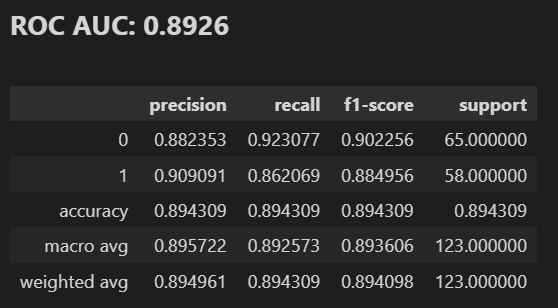

Топ 2 модель

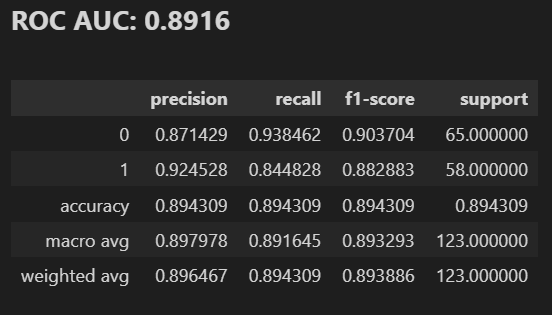

## net_impact

In [178]:
df_net_impact = df_logs[df_logs['Таргет']=='net_impact']
df_net_impact.sort_values(by=['F1', 'ROC AUC'], ascending=False, inplace=True)
df_net_impact.reset_index(inplace=True, drop=True)
display(df_net_impact.style.background_gradient(
    axis=0, 
    cmap='YlOrRd',
    subset=['F1', 'ROC AUC']
))

,Таргет,Модель,Датасет,F1,ROC AUC
0,net_impact,CatBoost + SMOTENC + optuna,alternative,0.919540,0.951220
1,net_impact,CatBoost + SMOTENC + optuna,united,0.888889,0.932927
2,net_impact,CatBoost + SMOTENC + optuna,pf,0.883721,0.920732
3,net_impact,RandomForest + SMOTENC + optuna,pf,0.837209,0.884146
4,net_impact,RandomForest + SMOTENC + optuna,united,0.823529,0.871951
5,net_impact,RandomForest + SMOTENC + optuna,alternative,0.823529,0.871951
6,net_impact,KNN + SMOTENC + optuna,pf,0.800000,0.847561
7,net_impact,KNN + SMOTENC + optuna,original,0.786517,0.847561
8,net_impact,CatBoost + SMOTENC + optuna,original,0.778947,0.847561
9,net_impact,RandomForest + SMOTENC + optuna,original,0.750000,0.810976


Топ 1 модель

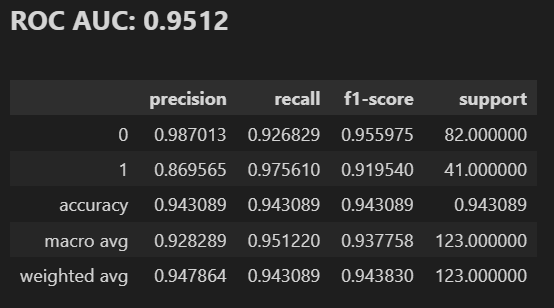

Топ 2 модель

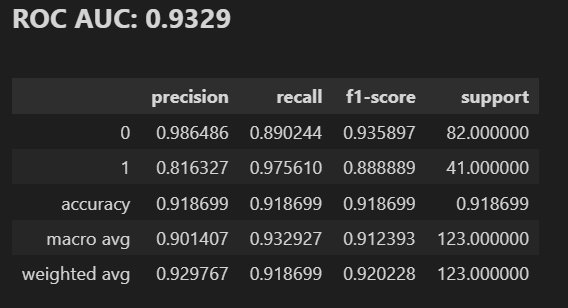